# imports

In [159]:
# ===========import============
from pathlib import Path

from data_provider import (
    set_seed,
    SEED,
    data_cleaner,
    make_clean_dataset,
    make_loader,
    ROOT,
    unclean_path,
    train_path,
    test_path,
)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18

# ===========control-randomness=============
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [160]:
# =========load-data============
if unclean_path.exists():
    print("unclean path exists")
else:
    raise FileNotFoundError("unclean path does not exist")

if train_path.exists():
    print("train path exists")
else:
    raise FileNotFoundError("train path does not exist")

if test_path.exists():
    print("test path exists")
else:
    raise FileNotFoundError("test path does not exist")


cleaner_output = data_cleaner(train_path, test_path, unclean_path)

dataset_train, dataset_train_base, dataset_test = make_clean_dataset(
    unclean_path, train_path, test_path, cleaner_output
)

_, train_base_loader, validation_loader, test_loader = make_loader(
    dataset_train, dataset_train_base, dataset_test
)

classes = dataset_train.classes

unclean path exists
train path exists
test path exists


# test Base-Model CNN

In [161]:
# =============Model-CNN-Base==============


class CnnBase(nn.Module):
    """CNN base class with 2 block Conv + acitvation + pooling"""

    def __init__(self, num_classes=8):
        super().__init__()

        # =====block-1=======
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=32, kernel_size=3, bias=False, padding=1
        )

        self.norm1 = nn.BatchNorm2d(num_features=32)
        # =======block-2========
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=False
        )

        self.norm2 = nn.BatchNorm2d(num_features=64)

        # =======block-3========
        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding=1, bias=False
        )

        self.norm3 = nn.BatchNorm2d(num_features=128)

        # =======block-4========
        self.conv4 = nn.Conv2d(
            in_channels=128, out_channels=256, kernel_size=3, padding=1, bias=False
        )

        self.norm4 = nn.BatchNorm2d(num_features=256)

        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # ========Classifier-Head=========
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_features=256, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=num_classes),
        )

    # ==========forward==========
    def forward(self, x):
        # ======layer-1=========
        out_conv1 = self.conv1(x)
        out_norm1 = self.norm1(out_conv1)
        out_relu = self.relu(out_norm1)
        out_max_pool1 = self.max_pool(out_relu)
        # =======layer-2=========
        out_conv2 = self.conv2(out_max_pool1)
        out_norm2 = self.norm2(out_conv2)
        out_relu2 = self.relu(out_norm2)
        out_max_pool2 = self.max_pool(out_relu2)
        # =======layer-3=========
        out_conv3 = self.conv3(out_max_pool2)
        out_norm3 = self.norm3(out_conv3)
        out_relu3 = self.relu(out_norm3)
        out_max_pool3 = self.max_pool(out_relu3)

        # =======layer-4=========
        out_conv4 = self.conv4(out_max_pool3)
        out_norm4 = self.norm4(out_conv4)
        out_relu4 = self.relu(out_norm4)
        out_max_pool4 = self.max_pool(out_relu4)
        # =======FC-layer=========
        out_fc = self.head(out_max_pool4)
        return out_fc

In [162]:
base_model_path = ROOT / "models" / "base_model" / "CNN-BaseModel.pth"

cnn_base = CnnBase()
state = torch.load(base_model_path, weights_only=True, map_location=DEVICE)

cnn_base.load_state_dict(state)

cnn_base.eval()

print("loaded successfully")

loaded successfully


In [163]:
logits_base = []
proba_base = []
preds_base = []
y_true = []
cnn_base.to(DEVICE)
for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true.extend(label.cpu().tolist())
    logit = cnn_base(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_base.extend(logit.cpu().tolist())
    preds_base.extend(pred.cpu().tolist())
    proba_base.extend(proba.values.cpu().tolist())

# reports

Mean confidence |   0.75                
              precision    recall  f1-score   support

   ambulance       0.62      0.94      0.75        50
     autobus       0.88      0.56      0.68        50
      kamyun       0.49      0.85      0.62        40
    kamyunet       0.69      0.15      0.25        60
     minibus       0.73      0.72      0.73        50
      savari       0.89      0.62      0.73        50
        taxi       0.94      0.94      0.94        50
       vanet       0.62      0.94      0.75        50

    accuracy                           0.70       400
   macro avg       0.73      0.71      0.68       400
weighted avg       0.74      0.70      0.67       400



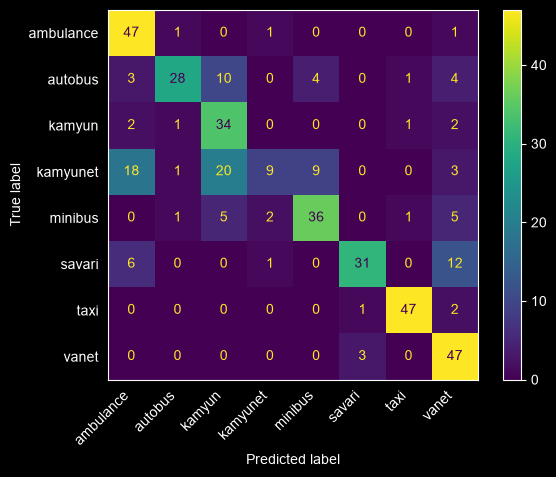

In [164]:
print(f"{'Mean confidence |':<20}{np.mean(proba_base):<20.2f}")

print(
    classification_report(
        y_true,
        preds_base,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, preds_base), display_labels=classes
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# Augmented

In [165]:
augmented_path = ROOT / "models" / "aug_model" / "CNN-AugModel.pth"

cnn_aug = CnnBase()
state = torch.load(augmented_path, weights_only=True, map_location=DEVICE)

cnn_aug.load_state_dict(state)

cnn_aug.eval()

print("loaded successfully")

loaded successfully


In [166]:
logits_aug = []
proba_aug = []
preds_aug = []
y_true_aug = []
cnn_aug.to(DEVICE)
for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_aug.extend(label.cpu().tolist())

    logit = cnn_aug(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_aug.extend(logit.cpu().tolist())
    preds_aug.extend(pred.cpu().tolist())
    proba_aug.extend(proba.values.cpu().tolist())

Mean confidence |   0.66                
              precision    recall  f1-score   support

   ambulance       0.62      0.90      0.74        50
     autobus       0.76      0.52      0.62        50
      kamyun       0.62      0.78      0.69        40
    kamyunet       0.44      0.45      0.44        60
     minibus       0.66      0.50      0.57        50
      savari       0.69      0.74      0.71        50
        taxi       0.85      0.94      0.90        50
       vanet       0.86      0.60      0.71        50

    accuracy                           0.67       400
   macro avg       0.69      0.68      0.67       400
weighted avg       0.68      0.67      0.66       400



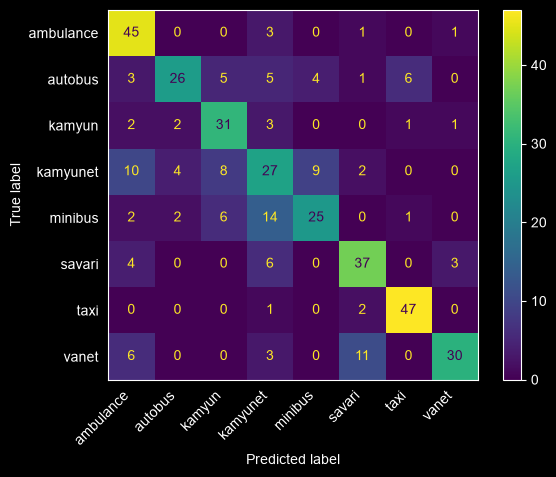

In [167]:
print(f"{'Mean confidence |':<20}{np.mean(proba_aug):<20.2f}")

print(
    classification_report(
        y_true_aug,
        preds_aug,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_aug, preds_aug), display_labels=classes
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# Resnet Finetune

In [168]:
resnet_path = ROOT / "models" / "resnet_finetune" / "resnet_finetune.pth"
resnet_finetune = resnet18()
in_feature = resnet_finetune.fc.in_features
resnet_finetune.fc = nn.Linear(in_features=in_feature, out_features=len(classes))
state = torch.load(resnet_path, weights_only=True, map_location=DEVICE)
resnet_finetune.load_state_dict(state)

resnet_finetune.eval()

print("loaded successfully")

loaded successfully


In [169]:
logits_resnet_fine = []
proba_resnet_fine = []
preds_resnet_fine = []
y_true_resnet_fine = []
resnet_finetune.to(DEVICE)

for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_resnet_fine.extend(label.cpu().tolist())

    logit = resnet_finetune(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_resnet_fine.extend(logit.cpu().tolist())
    preds_resnet_fine.extend(pred.cpu().tolist())
    proba_resnet_fine.extend(proba.values.cpu().tolist())

Mean confidence |   0.98                
              precision    recall  f1-score   support

   ambulance       0.98      0.94      0.96        50
     autobus       0.96      0.98      0.97        50
      kamyun       0.95      0.90      0.92        40
    kamyunet       0.95      0.93      0.94        60
     minibus       0.96      0.98      0.97        50
      savari       0.94      0.98      0.96        50
        taxi       1.00      0.96      0.98        50
       vanet       0.92      0.98      0.95        50

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



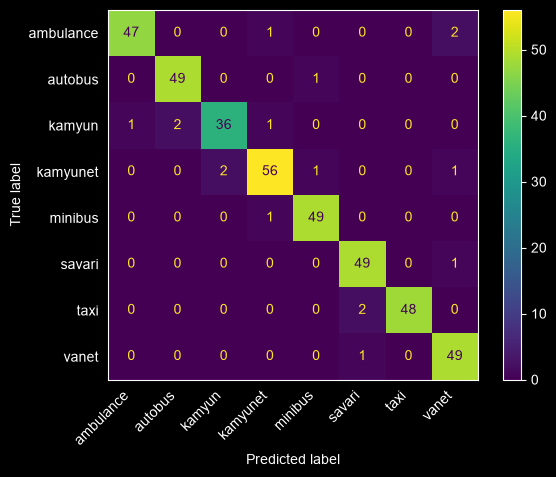

In [170]:
print(f"{'Mean confidence |':<20}{np.mean(proba_resnet_fine):<20.2f}")

print(
    classification_report(
        y_true_resnet_fine,
        preds_resnet_fine,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_resnet_fine, preds_resnet_fine),
    display_labels=classes,
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# resnet freeze

In [171]:
resnet_path = ROOT / "models" / "resnet_freeze" / "resnet_freeze.pth"
resnet_freeze = resnet18()
in_feature = resnet_freeze.fc.in_features
resnet_freeze.fc = nn.Linear(in_features=in_feature, out_features=len(classes))
state = torch.load(resnet_path, weights_only=True, map_location=DEVICE)
resnet_freeze.load_state_dict(state)

resnet_freeze.eval()

print("loaded successfully")

loaded successfully


In [172]:
logits_resnet_freeze = []
proba_resnet_freeze = []
preds_resnet_freeze = []
y_true_resnet_freeze = []
resnet_freeze.to(DEVICE)

for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_resnet_freeze.extend(label.cpu().tolist())

    logit = resnet_freeze(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_resnet_freeze.extend(logit.cpu().tolist())
    preds_resnet_freeze.extend(pred.cpu().tolist())
    proba_resnet_freeze.extend(proba.values.cpu().tolist())

Mean confidence |   0.85                
              precision    recall  f1-score   support

   ambulance       0.94      0.92      0.93        50
     autobus       0.90      0.90      0.90        50
      kamyun       0.84      0.78      0.81        40
    kamyunet       0.85      0.78      0.82        60
     minibus       0.86      0.98      0.92        50
      savari       0.91      0.96      0.93        50
        taxi       0.94      0.92      0.93        50
       vanet       0.92      0.92      0.92        50

    accuracy                           0.90       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.90      0.89       400



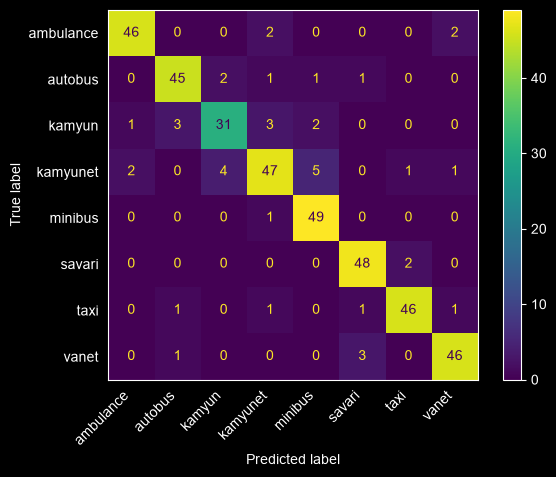

In [173]:
print(f"{'Mean confidence |':<20}{np.mean(proba_resnet_freeze):<20.2f}")

print(
    classification_report(
        y_true_resnet_freeze,
        preds_resnet_freeze,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_resnet_freeze, preds_resnet_freeze),
    display_labels=classes,
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# average pool

In [174]:
# =============Model-CNN-Average-Pool==============
class CnnAvgPool(nn.Module):
    """CNN with 4 Conv blocks and AvgPool2d (Ablation study on Pooling method)."""

    def __init__(self, num_classes=8):
        super().__init__()

        # ===== Block 1 =====
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.norm1 = nn.BatchNorm2d(32)

        # ===== Block 2 =====
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.norm2 = nn.BatchNorm2d(64)

        # ===== Block 3 =====
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.norm3 = nn.BatchNorm2d(128)

        # ===== Block 4 =====
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.norm4 = nn.BatchNorm2d(256)

        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # ===== Classifier Head =====
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_features=256, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=num_classes),
        )

    def forward(self, x):
        # Layer 1
        x = self.pool(self.relu(self.norm1(self.conv1(x))))
        # Layer 2
        x = self.pool(self.relu(self.norm2(self.conv2(x))))
        # Layer 3
        x = self.pool(self.relu(self.norm3(self.conv3(x))))
        # Layer 4
        x = self.pool(self.relu(self.norm4(self.conv4(x))))

        # FC Head
        return self.head(x)

In [175]:
avg_model_path = ROOT / "models" / "avgpool_model" / "CNN-avgPoolModel.pth"

cnn_avg = CnnAvgPool()
state = torch.load(avg_model_path, weights_only=True, map_location=DEVICE)

cnn_avg.load_state_dict(state)

cnn_avg.eval()

print("loaded successfully")

loaded successfully


In [176]:
logits_avg = []
proba_avg = []
preds_avg = []
y_true_avg = []
cnn_avg.to(DEVICE)
for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_avg.extend(label.cpu().tolist())

    logit = cnn_avg(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_avg.extend(logit.cpu().tolist())
    preds_avg.extend(pred.cpu().tolist())
    proba_avg.extend(proba.values.cpu().tolist())

Mean confidence |   0.68                
              precision    recall  f1-score   support

   ambulance       0.69      0.84      0.76        50
     autobus       0.81      0.50      0.62        50
      kamyun       0.49      0.82      0.61        40
    kamyunet       0.58      0.47      0.52        60
     minibus       0.64      0.60      0.62        50
      savari       0.58      0.60      0.59        50
        taxi       0.98      0.90      0.94        50
       vanet       0.74      0.70      0.72        50

    accuracy                           0.67       400
   macro avg       0.69      0.68      0.67       400
weighted avg       0.69      0.67      0.67       400



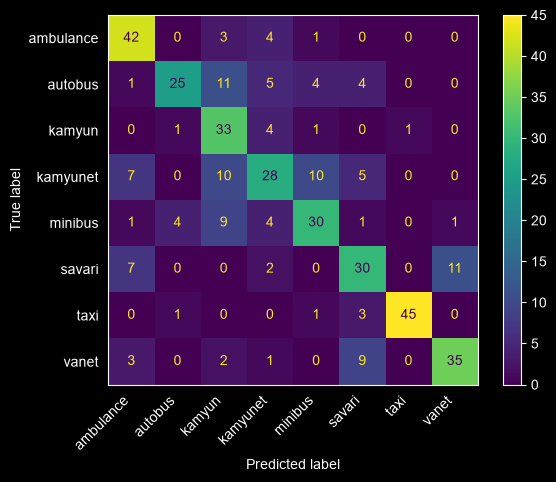

In [177]:
print(f"{'Mean confidence |':<20}{np.mean(proba_avg):<20.2f}")

print(
    classification_report(
        y_true_avg,
        preds_avg,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_avg, preds_avg), display_labels=classes
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# BCE loss vs Cross Entropy

In [178]:
bce_model_path = ROOT / "models" / "loss_experiment" / "CNN-BCEModel.pth"
cross_model_path = ROOT / "models" / "loss_experiment" / "CNN-CrossModel.pth"


cnn_bce = CnnBase()
state = torch.load(bce_model_path, weights_only=True, map_location=DEVICE)
cnn_bce.load_state_dict(state)
cnn_bce.eval()

cnn_cross = CnnBase()
state = torch.load(cross_model_path, weights_only=True, map_location=DEVICE)
cnn_cross.load_state_dict(state)
cnn_cross.eval()

print("loaded successfully")

loaded successfully


In [179]:
y_true = []

logits_bce = []
probas_bce = []
preds_bce = []

cnn_bce.to(DEVICE)

logits_cross = []
probas_cross = []
preds_cross = []
cnn_cross.to(DEVICE)


for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)

    y_true.extend(label.cpu().tolist())

    logit_bce = cnn_bce(image)
    logit_cross = cnn_cross(image)

    pred_bce = logit_bce.argmax(dim=1)
    pred_cross = logit_cross.argmax(dim=1)

    proba_bce = torch.softmax(logit_bce, dim=1).max(dim=1)
    proba_cross = torch.softmax(logit_cross, dim=1).max(dim=1)

    logits_bce.extend(logit_bce.cpu().tolist())
    logits_cross.extend(logit_cross.cpu().tolist())

    preds_bce.extend(pred_bce.cpu().tolist())
    preds_cross.extend(pred_cross.cpu().tolist())

    probas_bce.extend(proba_bce.values.cpu().tolist())
    probas_cross.extend(proba_cross.values.cpu().tolist())

Mean confidence Cross|0.75                
Mean confidence BCE|0.80                

BCE Loss 

              precision    recall  f1-score   support

   ambulance       0.67      0.94      0.78        50
     autobus       0.65      0.62      0.63        50
      kamyun       0.48      0.80      0.60        40
    kamyunet       0.62      0.38      0.47        60
     minibus       1.00      0.30      0.46        50
      savari       0.73      0.76      0.75        50
        taxi       0.96      0.90      0.93        50
       vanet       0.62      0.80      0.70        50

    accuracy                           0.68       400
   macro avg       0.72      0.69      0.67       400
weighted avg       0.72      0.68      0.66       400


Cross-Entropy

              precision    recall  f1-score   support

   ambulance       0.62      0.94      0.75        50
     autobus       0.88      0.56      0.68        50
      kamyun       0.49      0.85      0.62        40
    kamyunet       0

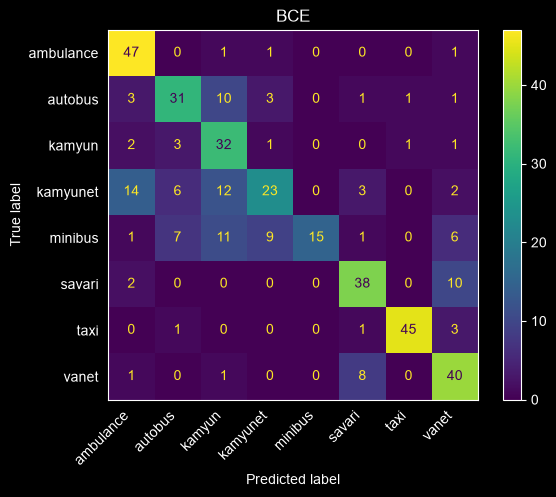

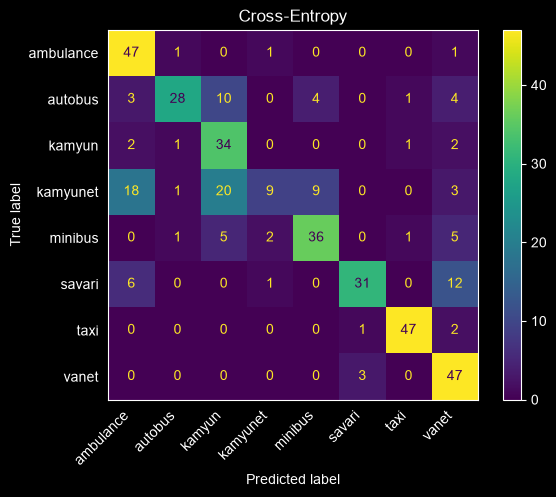

In [180]:
print(f"{'Mean confidence Cross|':<20}{np.mean(probas_cross):<20.2f}")

print(f"{'Mean confidence BCE|':<20}{np.mean(probas_bce):<20.2f}")
print("\nBCE Loss \n")
print(
    classification_report(
        y_true,
        preds_bce,
        target_names=classes,
        zero_division=0,
    )
)
print("\nCross-Entropy\n")
print(
    classification_report(
        y_true,
        preds_cross,
        target_names=classes,
        zero_division=0,
    )
)

dsp_bce = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, preds_bce), display_labels=classes
)
dsp_bce.plot()
plt.grid(False)
plt.title("BCE")
plt.xticks(rotation=45, ha="right")
plt.show()

dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, preds_cross), display_labels=classes
)
dsp.plot()
plt.grid(False)
plt.title("Cross-Entropy")
plt.xticks(rotation=45, ha="right")
plt.show()

# dropout

In [181]:
class CnnDropout(nn.Module):
    """CNN with 4 Conv blocks and Dropout in Classifier Head (Ablation study on Regularization)."""

    def __init__(self, num_classes=8, dropout_rate=0.3):
        super().__init__()

        # ===== Block 1 =====
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            bias=False,
            padding=1,
        )
        self.norm1 = nn.BatchNorm2d(num_features=32)

        # ===== Block 2 =====
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            bias=False,
            padding=1,
        )
        self.norm2 = nn.BatchNorm2d(num_features=64)

        # ===== Block 3 =====
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            bias=False,
            padding=1,
        )
        self.norm3 = nn.BatchNorm2d(num_features=128)

        # ===== Block 4 =====
        self.conv4 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            bias=False,
            padding=1,
        )
        self.norm4 = nn.BatchNorm2d(num_features=256)

        # ===== Utils =====
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # ===== Classifier Head =====
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_features=256, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features=256, out_features=num_classes),
        )

    def forward(self, x):
        # Layer 1
        out_conv1 = self.conv1(x)
        out_norm1 = self.norm1(out_conv1)
        out_relu1 = self.relu(out_norm1)
        out_max_pool1 = self.max_pool(out_relu1)

        # Layer 2
        out_conv2 = self.conv2(out_max_pool1)
        out_norm2 = self.norm2(out_conv2)
        out_relu2 = self.relu(out_norm2)
        out_max_pool2 = self.max_pool(out_relu2)

        # Layer 3
        out_conv3 = self.conv3(out_max_pool2)
        out_norm3 = self.norm3(out_conv3)
        out_relu3 = self.relu(out_norm3)
        out_max_pool3 = self.max_pool(out_relu3)

        # Layer 4
        out_conv4 = self.conv4(out_max_pool3)
        out_norm4 = self.norm4(out_conv4)
        out_relu4 = self.relu(out_norm4)
        out_max_pool4 = self.max_pool(out_relu4)

        # Classifier Head
        out_fc = self.head(out_max_pool4)
        return out_fc

In [182]:
drop3_path = ROOT / "models" / "dropout_model" / "CNN-DropoutModeldropout_3.pth"
state_3 = torch.load(drop3_path, weights_only=True)
cnn_3 = CnnDropout(dropout_rate=0.3).to(DEVICE)
cnn_3.load_state_dict(state_3)
cnn_3.eval()
drop5_path = ROOT / "models" / "dropout_model" / "CNN-DropoutModeldropout_5.pth"
state_5 = torch.load(drop5_path, weights_only=True)
cnn_5 = CnnDropout(dropout_rate=0.5).to(DEVICE)
cnn_5.load_state_dict(state_5)
cnn_5.eval()
print("loaded successfully")

loaded successfully


In [183]:
y_true = []

logits_3 = []
probas_3 = []
preds_3 = []

cnn_3.to(DEVICE)

logits_5 = []
probas_5 = []
preds_5 = []
cnn_5.to(DEVICE)


for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)

    y_true.extend(label.cpu().tolist())

    logit_3 = cnn_3(image)
    logit_5 = cnn_5(image)

    pred_3 = logit_3.argmax(dim=1)
    pred_5 = logit_5.argmax(dim=1)

    proba_3 = torch.softmax(logit_3, dim=1).max(dim=1)
    proba_5 = torch.softmax(logit_5, dim=1).max(dim=1)

    logits_3.extend(logit_3.cpu().tolist())
    logits_5.extend(logit_5.cpu().tolist())

    preds_3.extend(pred_3.cpu().tolist())
    preds_5.extend(pred_5.cpu().tolist())

    probas_3.extend(proba_3.values.cpu().tolist())
    probas_5.extend(proba_5.values.cpu().tolist())

Mean confidence 3|  0.69                
Mean confidence 5|  0.64                

Dropout 0.3 

              precision    recall  f1-score   support

   ambulance       0.93      0.82      0.87        50
     autobus       0.74      0.58      0.65        50
      kamyun       0.80      0.50      0.62        40
    kamyunet       0.74      0.42      0.53        60
     minibus       0.48      0.92      0.63        50
      savari       0.76      0.68      0.72        50
        taxi       0.81      0.96      0.88        50
       vanet       0.72      0.84      0.78        50

    accuracy                           0.71       400
   macro avg       0.75      0.71      0.71       400
weighted avg       0.75      0.71      0.71       400


Dropout 0.5

              precision    recall  f1-score   support

   ambulance       0.85      0.70      0.77        50
     autobus       0.59      0.38      0.46        50
      kamyun       0.71      0.30      0.42        40
    kamyunet       0.

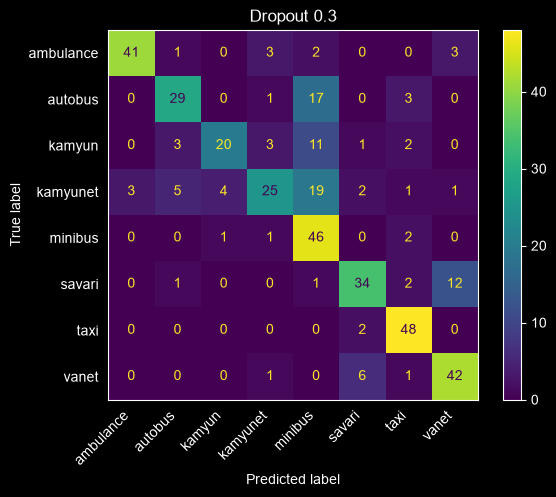

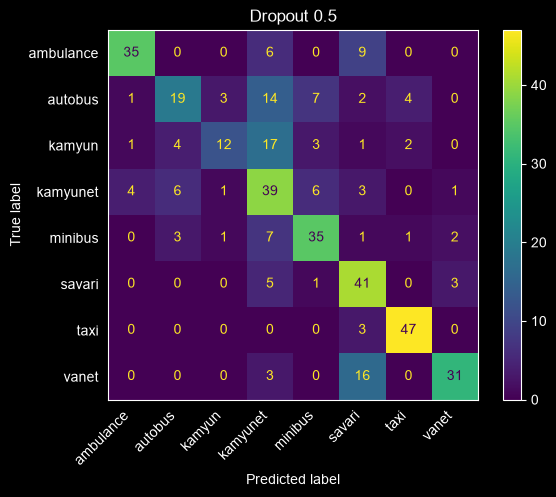

In [184]:
print(f"{'Mean confidence 3|':<20}{np.mean(probas_3):<20.2f}")

print(f"{'Mean confidence 5|':<20}{np.mean(probas_5):<20.2f}")
print("\nDropout 0.3 \n")
print(
    classification_report(
        y_true,
        preds_3,
        target_names=classes,
        zero_division=0,
    )
)
print("\nDropout 0.5\n")
print(
    classification_report(
        y_true,
        preds_5,
        target_names=classes,
        zero_division=0,
    )
)

dsp_3 = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, preds_3), display_labels=classes
)
dsp_3.plot()
plt.grid(False)
plt.title("Dropout 0.3")
plt.xticks(rotation=45, ha="right")
plt.show()

dsp_5 = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, preds_5), display_labels=classes
)
dsp_5.plot()
plt.grid(False)
plt.title("Dropout 0.5")
plt.xticks(rotation=45, ha="right")
plt.show()

# imbalance

In [185]:
imbalance_path = ROOT / "models" / "imbalance_model" / "CNN-ImbalanceModel.pth"
state = torch.load(imbalance_path, weights_only=True)

cnn_imb = CnnBase().to(DEVICE)

cnn_imb.load_state_dict(state)

print("loaded successfully")

loaded successfully


In [186]:
logits_imb = []
proba_imb = []
preds_imb = []
y_true_imb = []
cnn_imb.eval()
for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_imb.extend(label.cpu().tolist())

    logit = cnn_imb(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_imb.extend(logit.cpu().tolist())
    preds_imb.extend(pred.cpu().tolist())
    proba_imb.extend(proba.values.cpu().tolist())

Mean confidence |   0.76                
              precision    recall  f1-score   support

   ambulance       0.57      0.96      0.72        50
     autobus       0.67      0.66      0.67        50
      kamyun       0.68      0.70      0.69        40
    kamyunet       0.89      0.27      0.41        60
     minibus       0.81      0.70      0.75        50
      savari       0.65      0.82      0.73        50
        taxi       0.84      0.96      0.90        50
       vanet       0.78      0.70      0.74        50

    accuracy                           0.71       400
   macro avg       0.74      0.72      0.70       400
weighted avg       0.74      0.71      0.69       400



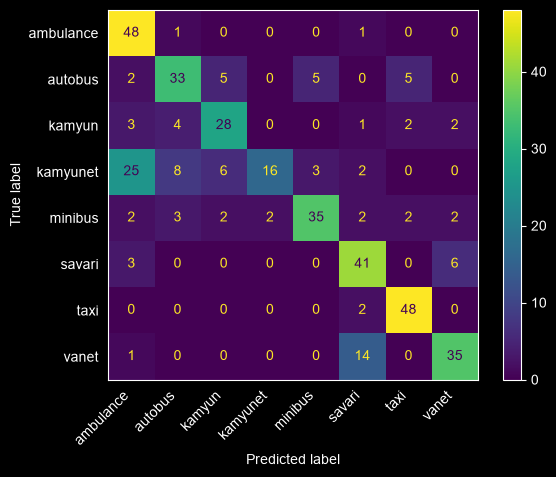

In [187]:
print(f"{'Mean confidence |':<20}{np.mean(proba_imb):<20.2f}")

print(
    classification_report(
        y_true_imb,
        preds_imb,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_imb, preds_imb), display_labels=classes
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# Learning Rate Scheduler

In [188]:
scheduler_path = ROOT / "models" / "scheduler_model" / "CNN-SchedulerModel.pth"

state = torch.load(scheduler_path, weights_only=True)
cnn_scheduler = CnnBase().to(DEVICE)
cnn_scheduler.load_state_dict(state)
print("loaded successfully")

loaded successfully


In [189]:
logits_scheduler = []
proba_scheduler = []
preds_scheduler = []
y_true_scheduler = []
cnn_scheduler.eval()

for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_scheduler.extend(label.cpu().tolist())

    logit = cnn_scheduler(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_scheduler.extend(logit.cpu().tolist())
    preds_scheduler.extend(pred.cpu().tolist())
    proba_scheduler.extend(proba.values.cpu().tolist())

Mean confidence |   0.66                
              precision    recall  f1-score   support

   ambulance       0.76      0.84      0.80        50
     autobus       0.60      0.60      0.60        50
      kamyun       0.70      0.75      0.72        40
    kamyunet       0.57      0.38      0.46        60
     minibus       0.66      0.74      0.70        50
      savari       0.65      0.82      0.73        50
        taxi       0.94      0.94      0.94        50
       vanet       0.81      0.70      0.75        50

    accuracy                           0.71       400
   macro avg       0.71      0.72      0.71       400
weighted avg       0.71      0.71      0.71       400



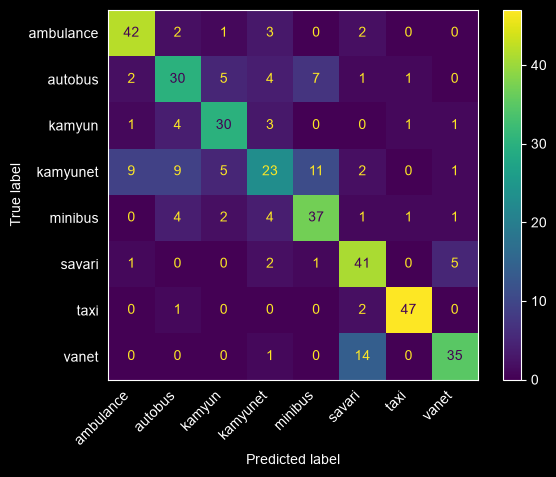

In [190]:
print(f"{'Mean confidence |':<20}{np.mean(proba_scheduler):<20.2f}")

print(
    classification_report(
        y_true_scheduler,
        preds_scheduler,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_scheduler, preds_scheduler),
    display_labels=classes,
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()

# Weight Decay

In [202]:
decay_path = ROOT / "models" / "decay_model" / "CNN-DecayModel.pth"
state = torch.load(decay_path, weights_only=True)

cnn_decay = CnnBase().to(DEVICE)
cnn_decay.load_state_dict(state)

print("Loaded successfully")

Loaded successfully


In [205]:
logits_decay = []
proba_decay = []
preds_decay = []
y_true_decay = []
cnn_decay.eval()

for image, label in test_loader:
    image, label = image.to(DEVICE), label.to(DEVICE)
    y_true_decay.extend(label.cpu().tolist())

    logit = cnn_decay(image)
    pred = logit.argmax(dim=1)
    proba = torch.softmax(logit, dim=1).max(dim=1)

    logits_decay.extend(logit.cpu().tolist())
    preds_decay.extend(pred.cpu().tolist())
    proba_decay.extend(proba.values.cpu().tolist())

Mean confidence |   0.75                
              precision    recall  f1-score   support

   ambulance       0.67      0.84      0.74        50
     autobus       0.92      0.44      0.59        50
      kamyun       0.40      0.88      0.55        40
    kamyunet       0.62      0.35      0.45        60
     minibus       0.74      0.74      0.74        50
      savari       0.97      0.60      0.74        50
        taxi       0.96      0.92      0.94        50
       vanet       0.73      0.92      0.81        50

    accuracy                           0.70       400
   macro avg       0.75      0.71      0.70       400
weighted avg       0.76      0.70      0.69       400



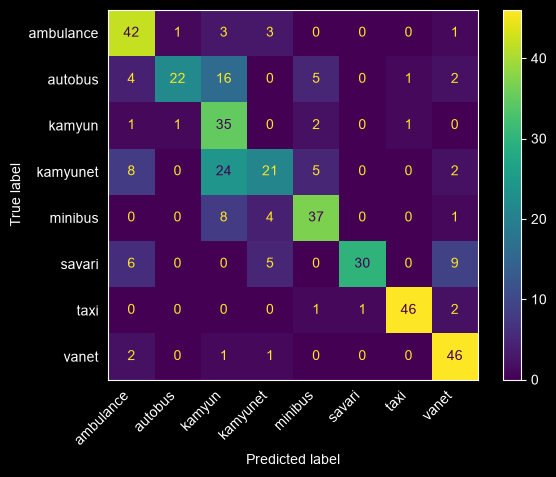

In [206]:
print(f"{'Mean confidence |':<20}{np.mean(proba_decay):<20.2f}")

print(
    classification_report(
        y_true_decay,
        preds_decay,
        target_names=classes,
        zero_division=0,
    )
)
dsp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_decay, preds_decay), display_labels=classes
)
dsp.plot()
plt.grid(False)
plt.xticks(rotation=45, ha="right")
plt.show()